In [1]:
import numpy as np
import os
import glob
from matplotlib import pyplot as plt

In [ ]:
#dir_path = 'output/single-body_2d_3classes/latent_None/H32-train1/20-03-10-32_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1'
#dir_path = 'output/single-body_2d_3classes/latent_None/H32-train1/20-03-01-51_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1'
#dir_path = '/work/dlclarge2/aliy-maskgit/maskgit/results/output_all/single-body_2d_3classes/pixel/discrete/first_run/H32-train1/03-05-13-19_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1'
#dir_path = '/work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/DiT/latent/continuous/MG/H32-train1/30-04-00-10_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1'
#dir_path = 'results/output_all/single-body_2d_3classes/DiT/latent/continuous/MG_1000/H32-train1/03-05-19-28_5000_1.6_256_1000_6000_0.0001_None_1500_2.0_1'
#dir_path = 'results/output_all/single-body_2d_3classes/DiT/latent/continuous/MG_1000/H32-train1/03-05-19-28_5000_1.6_256_1000_6000_0.0001_None_1500_2.0_1'
#dir_path = '/work/dlclarge2/aliy-maskgit/maskgit/results/output_all/single-body_2d_3classes/pixel/discrete/first_run/H32-train1/03-05-13-19_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1'
#dir_path = 'results/output_all/single-body_2d_3classes/DiT/latent/continuous/MG_500_padding/H32-train1/04-05-00-35_5000_1.6_256_1000_6000_0.0001_None_1500_2.0_1'
dir_path = 'results/output_all/single-body_2d_3classes/DiT/latent/discrete/XAI_4/H32-train1/04-05-16-12_5000_1.6_256_500_6000_0.0001_None_1500_2.0_4'
save_dir = 'output_old_script_disc_first_run'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
# Loop over all files in the directory
for filename in os.listdir(dir_path):
    if filename.endswith('.npz'):
        data = np.load(os.path.join(dir_path, filename))
        #print(data)
        #get the number between ep and .npz
        ep = filename.split('ep')[1].split('.npz')[0]
        #print(f'Epoch: {ep}')
        #print(f'File: {filename}, data: {data.files}, shape:{data[data.files[0]].shape}')
        # Assuming the .npz file contains only one array
        array_name = data.files[0] 
        if  array_name == 'x_gen' and int(ep) > 500: # and int(ep) < 2000:
            print(data[array_name].shape)
            # Assuming the array is 3D (e.g., 1xHxWxC)
            image_array = data[array_name][0].transpose(1, 2, 0)
            #print(f'Image max: {np.max(image_array)}, min: {np.min(image_array)}')
            #Display the image
            plt.imshow(image_array, cmap='gray')
            plt.title(f'Image from {filename}')
            plt.axis('off')
            plt.show()
            # Save the image to a file
            save_filename = f'{save_dir}/{filename.replace(".npz", ".png")}'
            #get ranges of the image
            print(f'Image max: {np.max(image_array)}, min: {np.min(image_array)}')
            #clip the image to 0-1
            image_array = np.clip(image_array, 0, 1)
            plt.imsave(save_filename, image_array, cmap='gray')
            plt.close()
            
            

Loaded 64 frames from image_111_ep899.npz


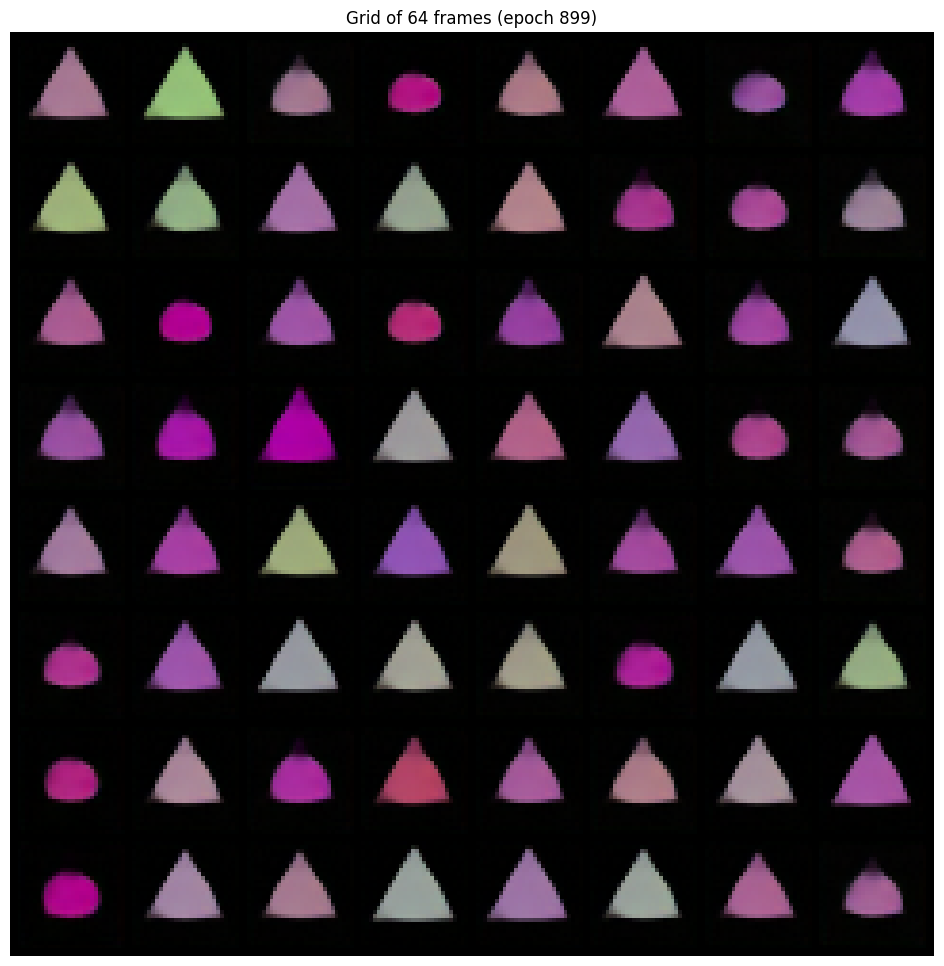

Saved grid image to output_old_script_disc_sec_run_val/image_111_ep899_grid.png


In [13]:
#dir_path = 'output/single-body_2d_3classes/latent_None/H32-train1/20-03-10-32_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1'
#dir_path = 'output/single-body_2d_3classes/latent_None/H32-train1/20-03-01-51_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1'
#dir_path = '/work/dlclarge2/aliy-maskgit/maskgit/results/output_all/single-body_2d_3classes/pixel/discrete/first_run/H32-train1/03-05-13-19_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1'
#dir_path = '/work/dlclarge2/aliy-maskgit/concept_graphs/results/output_all/single-body_2d_3classes/DiT/latent/continuous/MG/H32-train1/30-04-00-10_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1'
#dir_path = 'results/output_all/single-body_2d_3classes/DiT/latent/continuous/MG_1000/H32-train1/03-05-19-28_5000_1.6_256_1000_6000_0.0001_None_1500_2.0_1'
#dir_path = 'results/output_all/single-body_2d_3classes/DiT/latent/continuous/MG_1000/H32-train1/03-05-19-28_5000_1.6_256_1000_6000_0.0001_None_1500_2.0_1'
#dir_path = '/work/dlclarge2/aliy-maskgit/maskgit/results/output_all/single-body_2d_3classes/pixel/discrete/first_run/H32-train1/03-05-13-19_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1'
#dir_path = 'results/output_all/single-body_2d_3classes/DiT/latent/continuous/MG_500_padding/H32-train1/04-05-00-35_5000_1.6_256_1000_6000_0.0001_None_1500_2.0_1'
import torch

from torchvision.utils import make_grid

dir_path = 'results/output_all/single-body_2d_3classes/DiT/latent/discrete/sec_run_validate/H32-train1/05-05-17-10_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1'
save_dir = 'output_old_script_disc_sec_run_val'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
for filename in os.listdir(dir_path):
    if not filename.endswith('.npz'):
        continue

    # load file & extract epoch
    data = np.load(os.path.join(dir_path, filename))
    ep = filename.split('ep')[1].split('.npz')[0]

    # only process x_gen at ep 4399 with '111' in the name
    array_name = data.files[0]
    if array_name=='x_gen' and int(ep)==899 and '111' in filename:

        imgs_np = data[array_name]  # shape [N, C, H, W]
        print(f"Loaded {imgs_np.shape[0]} frames from {filename}")

        # clip into [0,1] if needed
        imgs_np = np.clip(imgs_np, 0.0, 1.0)

        # convert to torch tensor
        imgs = torch.from_numpy(imgs_np)  # N×C×H×W

        # make a grid: adjust nrow to change columns
        grid = make_grid(imgs, nrow=8, padding=2, normalize=False)

        # convert to H×W×C numpy for plotting
        grid_np = grid.permute(1, 2, 0).cpu().numpy()

        # display inline in notebook
        plt.figure(figsize=(12,12))
        if grid_np.shape[2] == 1:
            plt.imshow(grid_np.squeeze(), cmap='gray')
        else:
            plt.imshow(grid_np)
        plt.title(f"Grid of {imgs_np.shape[0]} frames (epoch {ep})")
        plt.axis('off')
        plt.show()

        # optional: save the grid out
        out_path = os.path.join(save_dir, f"{filename.replace('.npz','')}_grid.png")
        plt.imsave(out_path, 
                   grid_np.squeeze() if grid_np.shape[2]==1 else grid_np, 
                   cmap='gray' if grid_np.shape[2]==1 else None)
        print(f"Saved grid image to {out_path}")

        break

Loaded 64 frames from image_111_ep799.npz


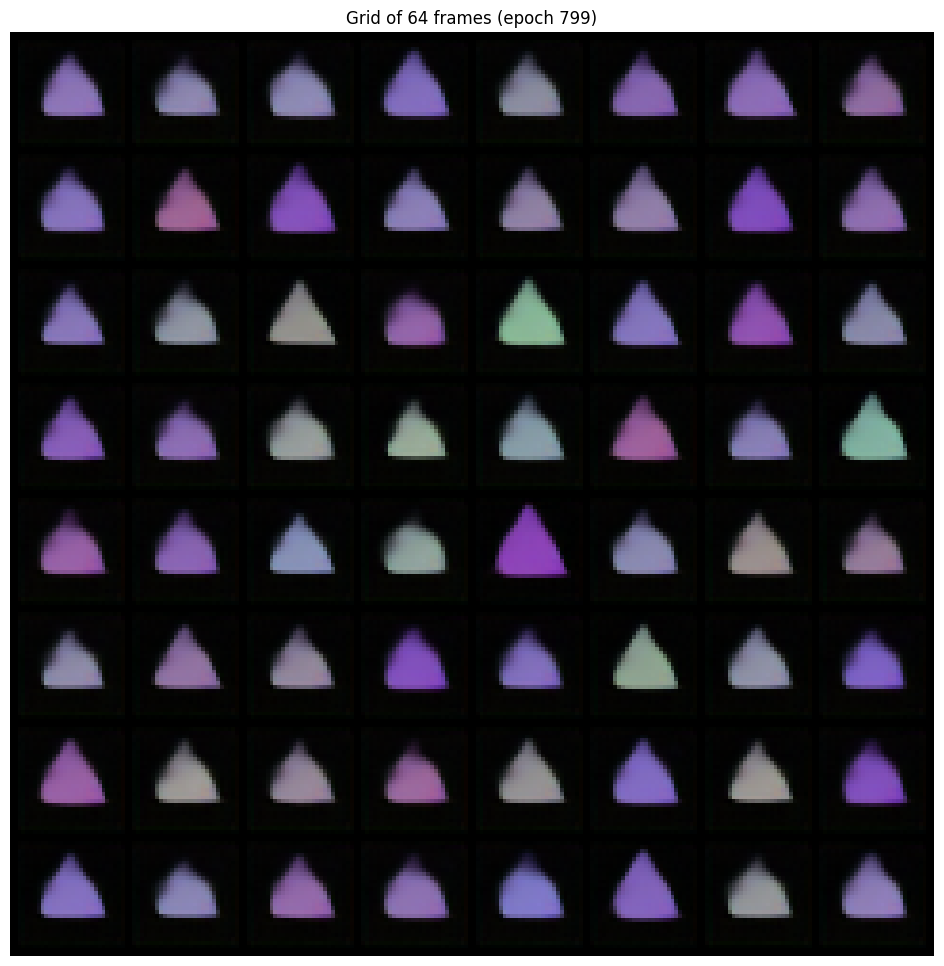

Saved grid image to output_old_script_disc_XAI_4/image_111_ep799_grid.png


In [ ]:
import torch

from torchvision.utils import make_grid

dir_path = 'results/output_all/single-body_2d_3classes/DiT/latent/discrete/sec_run/H32-train1/30-03-22-27_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1'

save_dir = 'output_old_script_disc_XAI_4'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
for filename in os.listdir(dir_path):
    if not filename.endswith('.npz'):
        continue

    # load file & extract epoch
    data = np.load(os.path.join(dir_path, filename))
    ep = filename.split('ep')[1].split('.npz')[0]

    # only process x_gen at ep 4399 with '111' in the name
    array_name = data.files[0]
    if array_name=='x_gen' and int(ep)==799 and '111' in filename:

        imgs_np = data[array_name]  # shape [N, C, H, W]
        print(f"Loaded {imgs_np.shape[0]} frames from {filename}")

        # clip into [0,1] if needed
        imgs_np = np.clip(imgs_np, 0.0, 1.0)

        # convert to torch tensor
        imgs = torch.from_numpy(imgs_np)  # N×C×H×W

        # make a grid: adjust nrow to change columns
        grid = make_grid(imgs, nrow=8, padding=2, normalize=False)

        # convert to H×W×C numpy for plotting
        grid_np = grid.permute(1, 2, 0).cpu().numpy()

        # display inline in notebook
        plt.figure(figsize=(12,12))
        if grid_np.shape[2] == 1:
            plt.imshow(grid_np.squeeze(), cmap='gray')
        else:
            plt.imshow(grid_np)
        plt.title(f"Grid of {imgs_np.shape[0]} frames (epoch {ep})")
        plt.axis('off')
        plt.show()

        # optional: save the grid out
        out_path = os.path.join(save_dir, f"{filename.replace('.npz','')}_grid.png")
        plt.imsave(out_path, 
                   grid_np.squeeze() if grid_np.shape[2]==1 else grid_np, 
                   cmap='gray' if grid_np.shape[2]==1 else None)
        print(f"Saved grid image to {out_path}")

        break